## Theory
Compare global thresholding, adaptive thresholding, and Otsu'smethod — when to use each.
- Global Thresholding: Uses a single `T` for all pixels. (high contrast, controlled lighting)
- Adaptive Thresholding: Calculates the best `T` for each local area and applies it while moving a kernel. (for variable lighting)
- Otsu's method: Calculates the best global `T` that maximizes a certain formula. (for bimodal histograms)

What is erosion? Give a practical use case.
- Its shrinking or `eroding` edges between elements.
- It has the ability to remove thin lines connecting objects which can be useful for scanned documents to remove bleeding ink between characters.

Explain CLAHE and why it's better than global histogram equalization.
- Performs histogram equalization on smaller tiles in the image which reduces noise and preserves local detail

Describe a full preprocessing pipeline for a noisy, low-contrast binary document image.
- Low-contrast: use CLAHE
- Noise: Use guassian blur
- Binarization: adaptive thresholding / otsu
- refinement: opening (erosion -> dialation) to preserve text thickness and remove noise

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [121]:
def grayScale(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

def blur(image):
    return cv2.GaussianBlur(image, (3, 3), 0)

def clahe(image):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(image)

def adaptiveThreshold(image):
    thresh = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 5, 5)
    return thresh

def opening(image):
    kernel = np.ones((2, 1), np.uint8)
    return cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)

def erode(image):
    kernel = np.ones((2, 1), np.uint8)
    return cv2.erode(image, kernel, iterations=3)

def gammaCorrection(image, gamma=1.0):
    corrected = np.power(image / 255.0, gamma) * 255.0
    return corrected

In [ ]:
def preprocess(image_path):
    # Loads the image
    image = cv2.imread(image_path)

    plt.figure(figsize=(25, 10))
    plt.subplot(1, 2, 1)
    plt.title('Original Image')
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    operations = [
        ('Convert to Grayscale', grayScale),
        ('Apply CLAHE', clahe),
        ('Apply Gaussian Blur', blur),
        ('Apply Adaptive Thresholding', adaptiveThreshold),
        ('Perform Morphological Opening', opening),
        # ('Perform Morphological Erosion', erode),
        ('Apply Gamma Correction', lambda img: gammaCorrection(img, gamma=10))
    ]


    for name, operation in operations:
        image = operation(image)
        print(f'{name} completed.')
    
    # Returns and displays the result alongside the original

    plt.subplot(1, 2, 2)
    plt.title('Preprocessed Image')
    plt.imshow(image, cmap='gray')
    plt.axis('off')
    plt.show()
    return image

Convert to Grayscale completed.
Apply CLAHE completed.
Apply Gaussian Blur completed.
Apply Adaptive Thresholding completed.
Perform Morphological Opening completed.
Apply Gamma Correction completed.


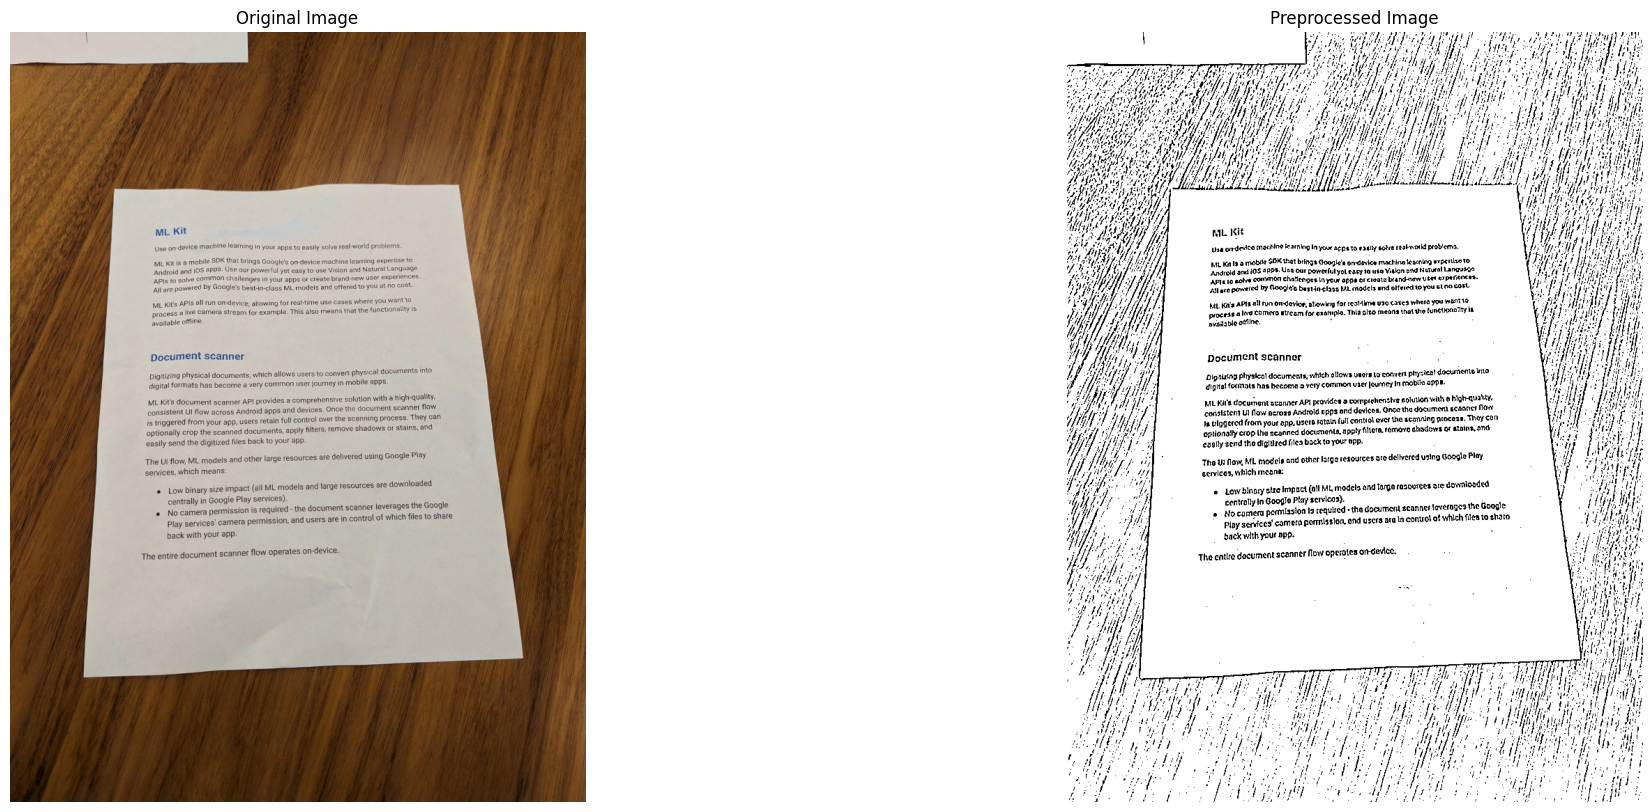

array([[255., 255., 255., ..., 255., 255., 255.],
       [255., 255., 255., ..., 255., 255., 255.],
       [255., 255., 255., ..., 255., 255., 255.],
       ...,
       [255., 255., 255., ..., 255., 255., 255.],
       [255., 255., 255., ..., 255., 255., 255.],
       [255., 255., 255., ..., 255., 255., 255.]], shape=(1106, 826))

In [123]:
preprocess('images/scanned.png')